In [4]:
%load_ext autoreload
%autoreload 2

In [6]:
import numpy as np
from src.minshap import minshap, max_p
from src.utils import load_mnist, get_patches
from src.models.nn import neural_net
from src.plotting import plot_saliency

from captum.attr import Saliency, InputXGradient, IntegratedGradients

2026-06-04 11:37:40.977 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /opt/anaconda3/lib/python3.10/site-packages


In [7]:
X_train, X_test, y_train, y_test = load_mnist(as_tensor=True)

# Take a smaller sample
X_train = X_train[:5_000]
y_train = y_train[:5_000]
X_test = X_test[:1_000]
y_test = y_test[:1_000]


model = neural_net(X_train, y_train)
patches = get_patches(7)

/opt/anaconda3/lib/python3.10/site-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)


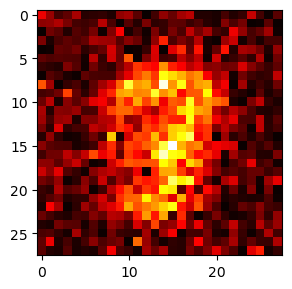

In [8]:
n = 0
input = X_test[n].unsqueeze(0)  # (1, 784)
target = y_test[n].unsqueeze(0)  # (1,)

saliency = Saliency(model.module_)
attribution = saliency.attribute(input, target=target)

fig, ax = plot_saliency(attribution, X_test, y_test, idx=n,show_image= False)
# fig.savefig(f'../plots/saliency_map_{n}', bbox_inches='tight')

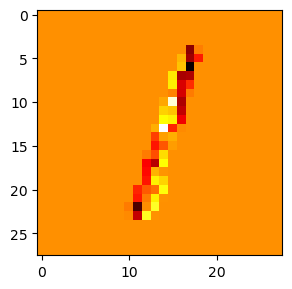

In [127]:
n = 2
input= X_test[n].unsqueeze(0)  # (1, 784)
target = y_test[n].unsqueeze(0)  # (1,)
input.requires_grad_(True)

ig = InputXGradient(model.module_)
attribution = ig.attribute(input, target=target)

fig, ax = plot_saliency(attribution, X_test, y_test, idx=n, show_image=False)
fig.savefig(f'../plots/input_x_gradient_{n}', bbox_inches='tight')

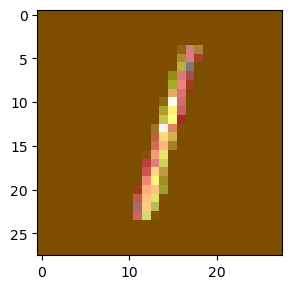

In [133]:
n = 2
input = X_test[n].unsqueeze(0)  # (1, 784)
target = y_test[n].unsqueeze(0)  # (1,)

ig = IntegratedGradients(model.module_)
attribution = ig.attribute(input, target=target, n_steps=50)

fig, ax = plot_saliency(attribution, X_test, y_test, idx=n)
fig.savefig(f'../plots/integrated_gradients_{n}', bbox_inches='tight')